# limpieza procesamiento de datos


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")

plt.rcParams['figure.figsize'] = (12,6)
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']
plt.rcParams['axes.unicode_minus'] = False

import warnings
warnings.filterwarnings('ignore')

print("Librerias cargadas correctamente")

Librerias cargadas correctamente


#git remote set-url origin https://github.com/raydelangel904-rgb/limpieza_datospandas.git

#git add .

#git commit -m "Mis prácticas locales de limpieza de datos con Pandas"

#git push -u origin main


# 📂 1. Importación y Carga de Datos

In [3]:
# Definir ruta del archivo original
file_path = "data/RNID-Delitos_Estatal-2026-abr2026.csv"

# Cargar el archivo con codificación latin1
try:
    df_raw = pd.read_csv(file_path, encoding='latin1')
    print(f"✅ Archivo cargado correctamente. Dimensiones del dataset original: {df_raw.shape[0]} filas y {df_raw.shape[1]} columnas.")
except Exception as e:
    print(f"❌ Error al cargar el archivo: {e}")

# Mostrar las primeras 5 filas del dataset original
df_raw.head()

✅ Archivo cargado correctamente. Dimensiones del dataset original: 3648 filas y 19 columnas.


,Año,Clave_Ent,Entidad,Bien jurídico afectado,Tipo de delito,Subtipo de delito,Modalidad,Enero,Febrero,Marzo,Abril,Mayo,Junio,Julio,Agosto,Septiembre,Octubre,Noviembre,Diciembre
0,2026,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma blanca,1,1,1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma de fuego,4,3,2,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2026,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con otro elemento,0,0,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2026,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,No especificado,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2026,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Tentativa de homicidio doloso,Tentativa de homicidio doloso,1,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# 🔍 2. Diagnóstico  de la calidad de datos

In [4]:
print("----- Información del Database---")
df_raw.info()

# Análisis de valores nulos
print("\n------ Valores Nulos por Columna")
nulls = df_raw.isnull().sum()
print(nulls[nulls>0] if nulls.sum() >0 else "No se encuentraron valores." )

# 3.  Análisis de valores duplicados
duplicates_count= df_raw.duplicated().sum()
print(f"\n------ Valores Duplicados --- \nCantidad de duplicados: {duplicates_count}")

# 4. Estadísticas para verificar anomalias numéricas

print("\n ---- Estadísticas descritivas (Enero - Abril) ----")
df_raw[['Enero','Febrero','Marzo','Abril']].describe()



----- Información del Database---
<class 'pandas.DataFrame'>
RangeIndex: 3648 entries, 0 to 3647
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Año                     3648 non-null   int64  
 1   Clave_Ent               3648 non-null   int64  
 2   Entidad                 3648 non-null   str    
 3   Bien jurídico afectado  3648 non-null   str    
 4   Tipo de delito          3648 non-null   str    
 5   Subtipo de delito       3648 non-null   str    
 6   Modalidad               3648 non-null   str    
 7   Enero                   3648 non-null   int64  
 8   Febrero                 3648 non-null   int64  
 9   Marzo                   3648 non-null   int64  
 10  Abril                   3648 non-null   int64  
 11  Mayo                    0 non-null      float64
 12  Junio                   0 non-null      float64
 13  Julio                   0 non-null      float64
 14  Agosto           

,Enero,Febrero,Marzo,Abril
count,3648.000000,3648.000000,3648.000000,3648.000000
mean,42.509046,41.278783,48.045504,46.988487
std,192.781886,174.861659,190.390442,203.210923
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,1.000000,1.000000,1.000000,1.000000
75%,20.000000,20.000000,24.000000,23.000000
max,7821.000000,6275.000000,5648.000000,7574.000000


# 📍 3. Estandarización de nombres columnas y Texto

In [5]:
# Generar una copia del Dataset
df_clean = df_raw.copy()

# 1. Renombrar columnas con snake_case

columnas_renombradas = {
    'Año': 'anio',
    'Clave_Ent': 'clave_ent',
    'Entidad': 'entidad',
    'Bien jurídico afectado': 'bien_juridico_afectado',
    'Tipo de delito': 'tipo_delito',
    'Subtipo de delito': 'subtipo_delito',
    'Modalidad': 'modalidad',
    'Enero': 'enero',
    'Febrero': 'febrero',
    'Marzo': 'marzo',
    'Abril': 'abril',
    'Mayo': 'mayo',
    'Junio': 'junio',
    'Julio': 'julio',
    'Agosto': 'agosto',
    'Septiembre': 'septiembre',
    'Octubre': 'octubre',
    'Noviembre': 'noviembre',
    'Diciembre': 'diciembre'
}
df_clean.rename(columns=columnas_renombradas, inplace=True)

# 2. Formateo 'clave_ent' (2 digitos decimales)

df_clean['clave_ent'] = df_clean['clave_ent'].astype(str).str.zfill(2)

# 3. Limpiar espacios en blanco

columnas_texto = ['entidad', 'bien_juridico_afectado', 'tipo_delito', 'subtipo_delito', 'modalidad']
for col in columnas_texto:
    df_clean[col] = df_clean[col].astype(str).str.strip()

print("✅ Columnas renombradas y texto")
df_clean.head()


✅ Columnas renombradas y texto


,anio,clave_ent,entidad,bien_juridico_afectado,tipo_delito,subtipo_delito,modalidad,enero,febrero,marzo,abril,mayo,junio,julio,agosto,septiembre,octubre,noviembre,diciembre
0,2026,01,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma blanca,1,1,1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026,01,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma de fuego,4,3,2,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2026,01,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con otro elemento,0,0,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2026,01,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,No especificado,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2026,01,Aguascalientes,La vida y la Integridad corporal,Homicidio,Tentativa de homicidio doloso,Tentativa de homicidio doloso,1,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# 🗑️ 4. Tratamiento de Columnas Vacías

In [6]:
meses_vacios = ['mayo', 'junio', 'julio', 'agosto', 'septiembre', 'octubre', 'noviembre', 'diciembre']

# Eliminar las columnas
df_clean.drop(columns=meses_vacios, inplace=True)

print(f"✅ Se eliminaron {len(meses_vacios)} columnas de meses futuros sin datos")
print(f"Nuevas dimensiones del Dataset: {df_clean.shape}")

df_clean.head()

✅ Se eliminaron 8 columnas de meses futuros sin datos
Nuevas dimensiones del Dataset: (3648, 11)


,anio,clave_ent,entidad,bien_juridico_afectado,tipo_delito,subtipo_delito,modalidad,enero,febrero,marzo,abril
0,2026,01,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma blanca,1,1,1,2
1,2026,01,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma de fuego,4,3,2,5
2,2026,01,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con otro elemento,0,0,1,1
3,2026,01,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,No especificado,0,0,0,0
4,2026,01,Aguascalientes,La vida y la Integridad corporal,Homicidio,Tentativa de homicidio doloso,Tentativa de homicidio doloso,1,0,1,0


# 5. Transformación a formato tidy Data

In [7]:
# Columnas identificadoras que se mantendrán fijas

id_vars = ['anio', 'clave_ent', 'entidad', 'bien_juridico_afectado', 'tipo_delito', 'subtipo_delito', 'modalidad']

# Columnas de valor para pivotar
value_vars= ['enero', 'febrero', 'marzo', 'abril']

# Aplicar .melt() para cambiar a formato largo

df_tidy= pd.melt(
    df_clean,
    id_vars=id_vars,
    value_vars=value_vars,
    var_name='mes',
    value_name='cantidad'
)

# mejorar la presentación de los nombres de mes
df_tidy['mes'] = df_tidy['mes'].str.capitalize()

print(f"✅ Reestructuración exitosa. Filas resultantes: {df_tidy.shape[0]}")

df_tidy.head()

✅ Reestructuración exitosa. Filas resultantes: 14592


,anio,clave_ent,entidad,bien_juridico_afectado,tipo_delito,subtipo_delito,modalidad,mes,cantidad
0,2026,01,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma blanca,Enero,1
1,2026,01,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma de fuego,Enero,4
2,2026,01,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con otro elemento,Enero,0
3,2026,01,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,No especificado,Enero,0
4,2026,01,Aguascalientes,La vida y la Integridad corporal,Homicidio,Tentativa de homicidio doloso,Tentativa de homicidio doloso,Enero,1


# ☎️ 6. Enriquecimiento del Dataset

In [8]:
 #Diccionario para mapear los meses en español a números
meses_mapping = {
    'Enero': 1,
    'Febrero': 2,
    'Marzo': 3,
    'Abril': 4
}

# Crear columna auxiliar numérica para el mes
df_tidy['mes_num'] = df_tidy['mes'].map(meses_mapping)

# Crear la columna de fecha (suponiendo el primer día del mes para indexación de series de tiempo)
df_tidy['fecha'] = pd.to_datetime(
    df_tidy['anio'].astype(str) + '-' + df_tidy['mes_num'].astype(str).str.zfill(2) + '-01'
)

# Eliminar columna auxiliar numérica
df_tidy.drop(columns=['mes_num'], inplace=True)

print("✅ Columna de fecha temporal creada exitosamente.")
df_tidy.head()

✅ Columna de fecha temporal creada exitosamente.


,anio,clave_ent,entidad,bien_juridico_afectado,tipo_delito,subtipo_delito,modalidad,mes,cantidad,fecha
0,2026,01,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma blanca,Enero,1,2026-01-01
1,2026,01,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma de fuego,Enero,4,2026-01-01
2,2026,01,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con otro elemento,Enero,0,2026-01-01
3,2026,01,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,No especificado,Enero,0,2026-01-01
4,2026,01,Aguascalientes,La vida y la Integridad corporal,Homicidio,Tentativa de homicidio doloso,Tentativa de homicidio doloso,Enero,1,2026-01-01


# 7. 💹 Graficación de Datos

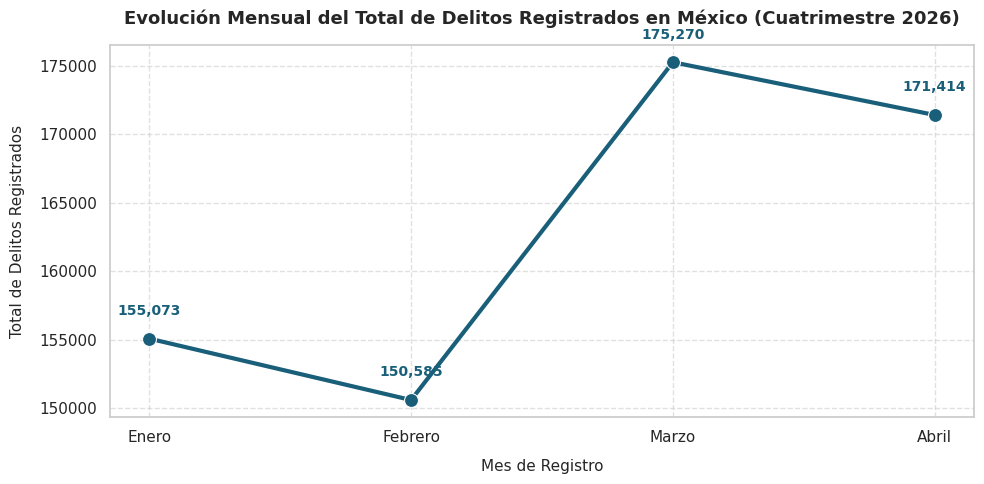

In [9]:
# 1. Evolución Mensual del Total de Delitos a Nivel Nacional
delitos_mensuales = df_tidy.groupby('mes')['cantidad'].sum().reindex(['Enero', 'Febrero', 'Marzo', 'Abril']).reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=delitos_mensuales,
    x='mes',
    y='cantidad',
    marker='o',
    markersize=10,
    linewidth=3,
    color='#1a5f7a'
)

plt.title("Evolución Mensual del Total de Delitos Registrados en México (Cuatrimestre 2026)", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Mes de Registro", fontsize=11, labelpad=10)
plt.ylabel("Total de Delitos Registrados", fontsize=11, labelpad=10)
plt.grid(True, linestyle="--", alpha=0.6)

for x, y in zip(delitos_mensuales['mes'], delitos_mensuales['cantidad']):
    plt.text(x, y + 1500, f"{int(y):,}", ha='center', va='bottom', fontsize=10, fontweight='bold', color="#1a5f7a")

plt.tight_layout()
plt.show()

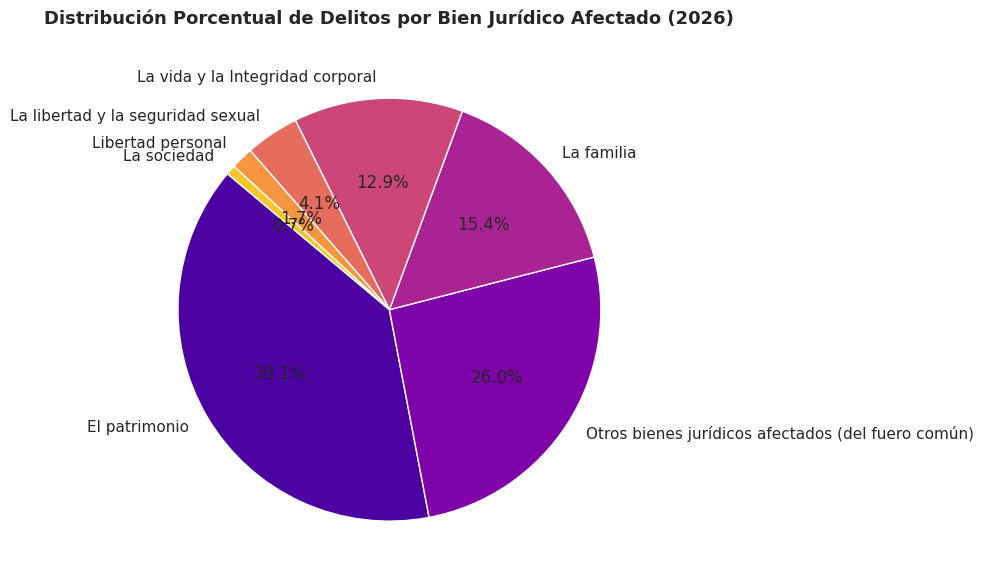

In [10]:
# 2. Distribución de Delitos por Bien Jurídico Afectado
bienes_afectados = df_tidy.groupby('bien_juridico_afectado')['cantidad'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
colors = sns.color_palette("plasma", len(bienes_afectados))
plt.pie(
    bienes_afectados['cantidad'],
    labels=bienes_afectados['bien_juridico_afectado'],
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1, 'antialiased': True}
)

plt.title("Distribución Porcentual de Delitos por Bien Jurídico Afectado (2026)", fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

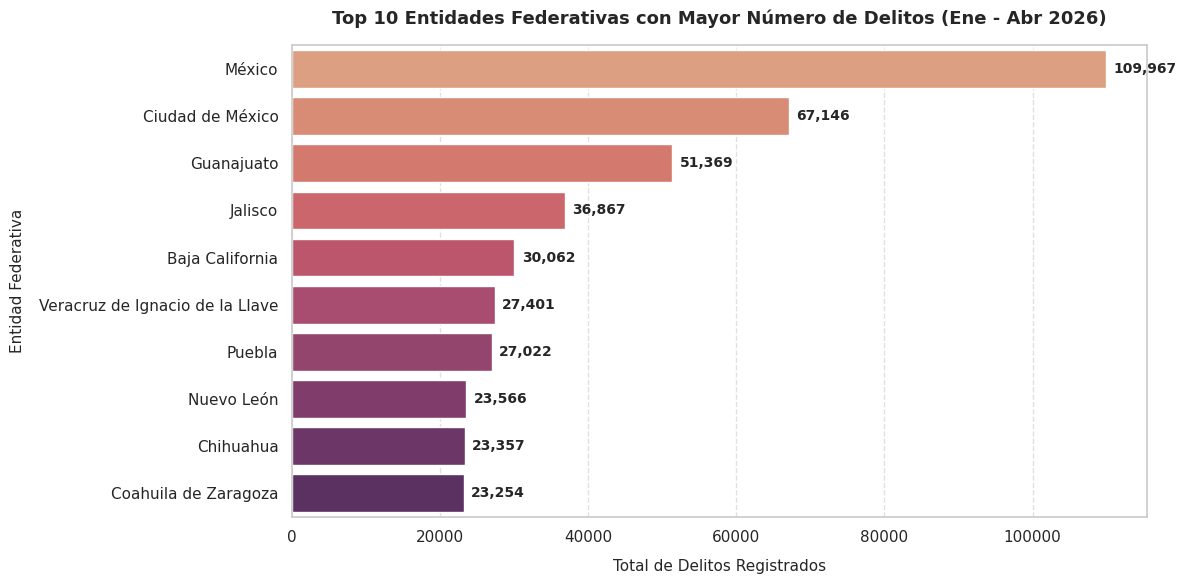

In [11]:
# 3. Top 10 Entidades Federativas con Mayor Incidencia Delictiva
entidades_incidencia = df_tidy.groupby('entidad')['cantidad'].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(
    data=entidades_incidencia,
    x='cantidad',
    y='entidad',
    palette="flare"
)

plt.title("Top 10 Entidades Federativas con Mayor Número de Delitos (Ene - Abr 2026)", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Total de Delitos Registrados", fontsize=11, labelpad=10)
plt.ylabel("Entidad Federativa", fontsize=11, labelpad=10)
plt.grid(axis='x', linestyle="--", alpha=0.6)

for index, value in enumerate(entidades_incidencia['cantidad']):
    plt.text(value + 1000, index, f"{int(value):,}", va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

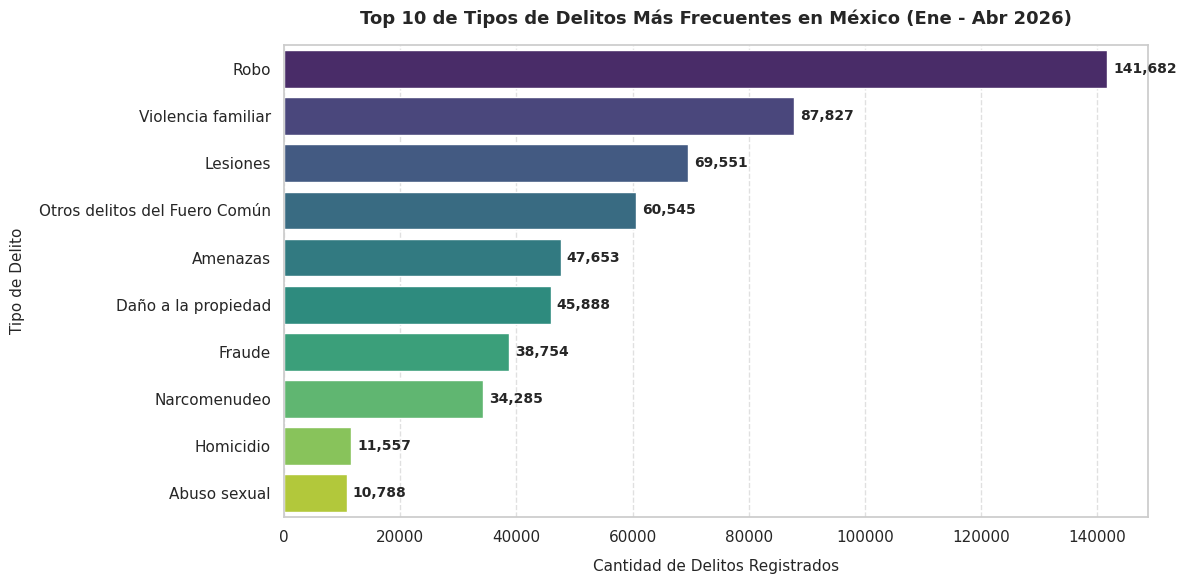

In [12]:
# 4. Top 10 de Tipos de Delito Más Frecuentes
delitos_tipos = df_tidy.groupby('tipo_delito')['cantidad'].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(
    data=delitos_tipos,
    x='cantidad',
    y='tipo_delito',
    palette="viridis"
)

plt.title("Top 10 de Tipos de Delitos Más Frecuentes en México (Ene - Abr 2026)", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Cantidad de Delitos Registrados", fontsize=11, labelpad=10)
plt.ylabel("Tipo de Delito", fontsize=11, labelpad=10)
plt.grid(axis='x', linestyle="--", alpha=0.6)

for index, value in enumerate(delitos_tipos['cantidad']):
    plt.text(value + 1000, index, f"{int(value):,}", va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

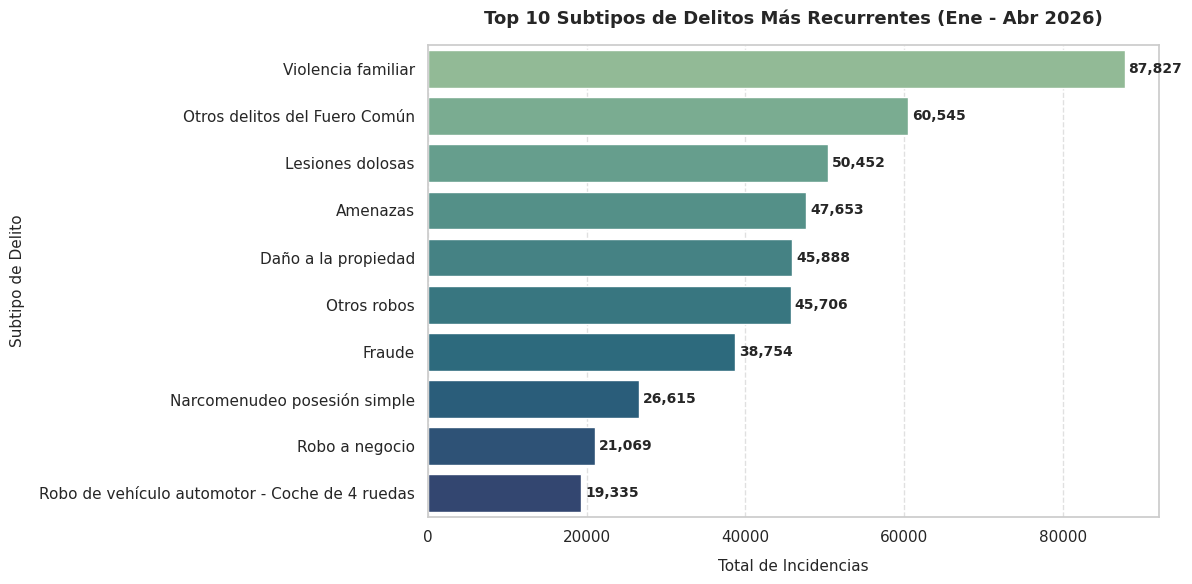

In [13]:
# 5. Top 10 Subtipos de Delitos Más Recurrentes
subtipos_incidencia = df_tidy.groupby('subtipo_delito')['cantidad'].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(
    data=subtipos_incidencia,
    x='cantidad',
    y='subtipo_delito',
    palette="crest"
)

plt.title("Top 10 Subtipos de Delitos Más Recurrentes (Ene - Abr 2026)", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Total de Incidencias", fontsize=11, labelpad=10)
plt.ylabel("Subtipo de Delito", fontsize=11, labelpad=10)
plt.grid(axis='x', linestyle="--", alpha=0.6)

for index, value in enumerate(subtipos_incidencia['cantidad']):
    plt.text(value + 500, index, f"{int(value):,}", va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

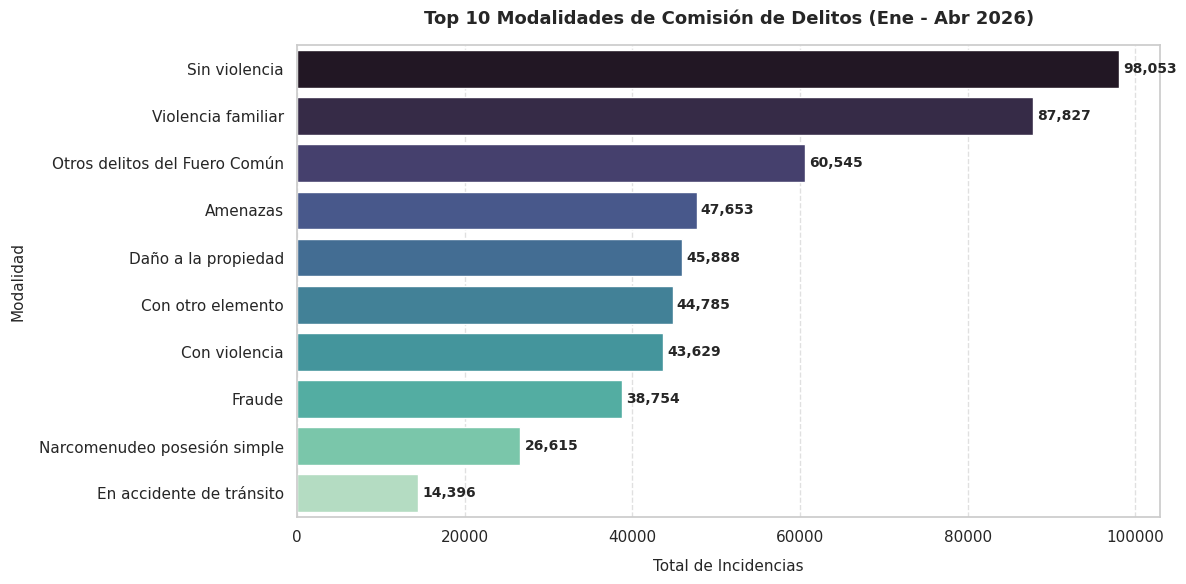

In [14]:
# 6. Top 10 Modalidades de Comisión de Delitos
modalidades_incidencia = df_tidy.groupby('modalidad')['cantidad'].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(
    data=modalidades_incidencia,
    x='cantidad',
    y='modalidad',
    palette="mako"
)

plt.title("Top 10 Modalidades de Comisión de Delitos (Ene - Abr 2026)", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Total de Incidencias", fontsize=11, labelpad=10)
plt.ylabel("Modalidad", fontsize=11, labelpad=10)
plt.grid(axis='x', linestyle="--", alpha=0.6)

for index, value in enumerate(modalidades_incidencia['cantidad']):
    plt.text(value + 500, index, f"{int(value):,}", va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# 🧐 8. Análisis Exploratorio de Datos (EDA) Avanzado

Habiendo completado la fase de limpieza y transformación de los datos a un formato estructurado y enriquecido ("Tidy Data"), procederemos a realizar un **Análisis Exploratorio de Datos (EDA)** detallado. El objetivo de esta sección es descubrir patrones ocultos, identificar los focos de mayor incidencia delictiva, analizar la temporalidad a corto plazo y comprender la composición de la delincuencia en México durante el primer cuatrimestre de 2026.

### Objetivos del EDA Avanzado:
1. **Distribución por Bien Jurídico:** Identificar cuáles son los derechos y bienes de los ciudadanos más afectados por la delincuencia.
2. **Análisis Geográfico:** Determinar qué estados concentran la mayor cantidad absoluta de delitos y cuáles presentan cifras más bajas.
3. **Foco en Delitos de Alto Impacto:** Analizar de manera particular los homicidios y sus modalidades (armas de fuego, armas blancas, etc.).
4. **Tendencias Temporales:** Observar la evolución y estacionalidad de los 5 delitos más comunes durante el periodo Enero-Abril.
5. **Comportamiento del Robo:** Desglosar el delito de robo para entender sus variantes y niveles de violencia.


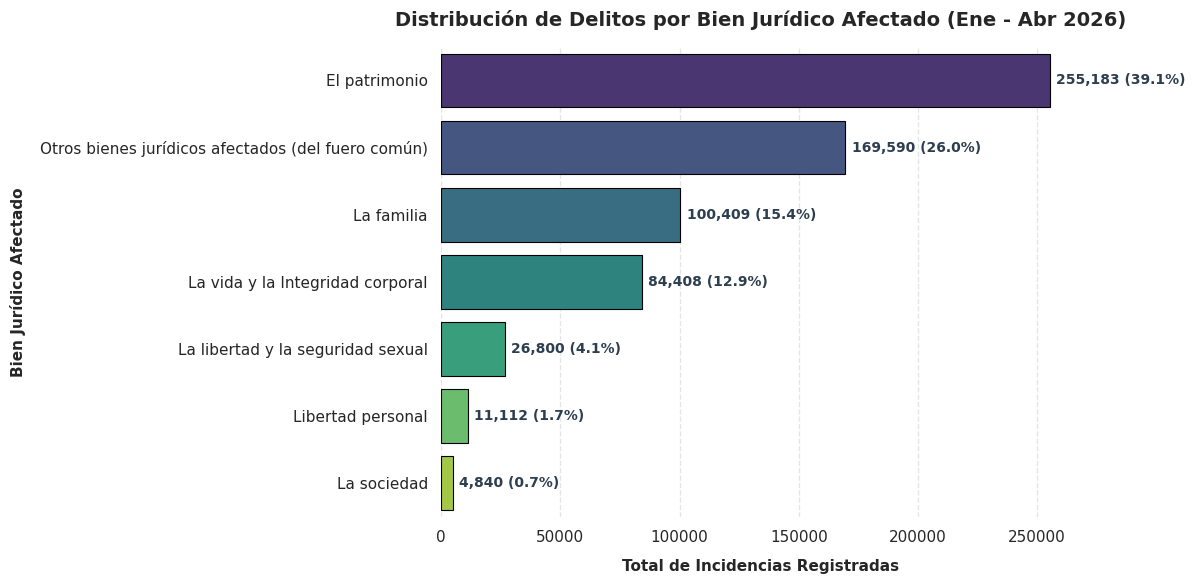

In [15]:
# 1. Agrupación y cálculo del total por Bien Jurídico Afectado
bien_juridico_stats = df_tidy.groupby('bien_juridico_afectado')['cantidad'].sum().sort_values(ascending=False).reset_index()
bien_juridico_stats['porcentaje'] = (bien_juridico_stats['cantidad'] / bien_juridico_stats['cantidad'].sum()) * 100

# Configuración del estilo visual premium
plt.figure(figsize=(12, 6))
colors = sns.color_palette("viridis", len(bien_juridico_stats))

ax = sns.barplot(
    data=bien_juridico_stats,
    x='cantidad',
    y='bien_juridico_afectado',
    palette=colors,
    edgecolor='black',
    linewidth=0.8
)

# Añadir etiquetas de valores y porcentajes en las barras
for i, bar in enumerate(ax.patches):
    width = bar.get_width()
    percentage = bien_juridico_stats.loc[i, 'porcentaje']
    ax.text(
        width + (bien_juridico_stats['cantidad'].max() * 0.01),
        bar.get_y() + bar.get_height()/2,
        f"{int(width):,} ({percentage:.1f}%)",
        va='center',
        ha='left',
        fontsize=10,
        fontweight='bold',
        color='#2c3e50'
    )

plt.title("Distribución de Delitos por Bien Jurídico Afectado (Ene - Abr 2026)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Total de Incidencias Registradas", fontsize=11, fontweight='bold', labelpad=10)
plt.ylabel("Bien Jurídico Afectado", fontsize=11, fontweight='bold', labelpad=10)
plt.grid(axis='x', linestyle="--", alpha=0.5)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()


*   **Interpretación:**
    *   **El patrimonio** es, por un amplio margen, el bien jurídico más afectado por la delincuencia (representando la gran mayoría de las incidencias). Esto es sumamente común en las estadísticas de seguridad pública, dado que los delitos patrimoniales (como el robo) representan el mayor volumen de denuncias ante el Ministerio Público.
    *   **La vida y la Integridad corporal** ocupa el segundo lugar, lo cual es de suma importancia ya que aquí se encuentran los delitos de más alto impacto (como homicidios, lesiones y feminicidios), que definen directamente la percepción de seguridad física y el bienestar social.
    *   **Libertad personal** y **La libertad y la seguridad sexual** muestran incidencias menores en términos absolutos pero representan delitos de extrema gravedad que requieren de un análisis focalizado y de políticas de prevención altamente especializadas.

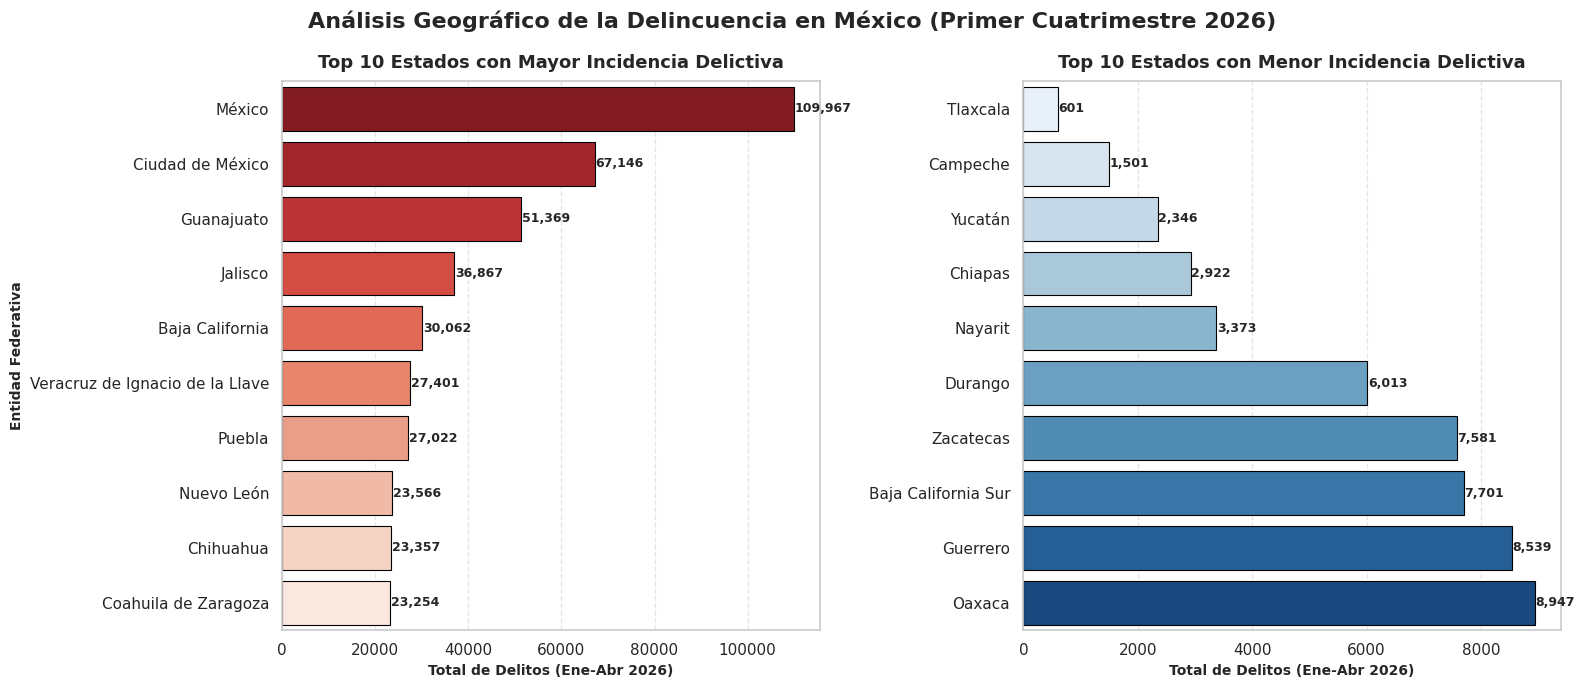

In [16]:
# 2. Agrupar delitos por entidad federativa
entidades_stats = df_tidy.groupby('entidad')['cantidad'].sum().sort_values(ascending=False).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Gráfico de los 10 estados con mayor incidencia
sns.barplot(
    data=entidades_stats.head(10),
    x='cantidad',
    y='entidad',
    palette="Reds_r",
    ax=axes[0],
    edgecolor='black',
    linewidth=0.8
)
axes[0].set_title("Top 10 Estados con Mayor Incidencia Delictiva", fontsize=13, fontweight='bold', pad=10)
axes[0].set_xlabel("Total de Delitos (Ene-Abr 2026)", fontsize=10, fontweight='bold')
axes[0].set_ylabel("Entidad Federativa", fontsize=10, fontweight='bold')
axes[0].grid(axis='x', linestyle="--", alpha=0.5)
for i, bar in enumerate(axes[0].patches):
    axes[0].text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2, f"{int(bar.get_width()):,}", va='center', fontsize=9, fontweight='bold')

# Gráfico de los 10 estados con menor incidencia
sns.barplot(
    data=entidades_stats.tail(10).sort_values('cantidad'),
    x='cantidad',
    y='entidad',
    palette="Blues",
    ax=axes[1],
    edgecolor='black',
    linewidth=0.8
)
axes[1].set_title("Top 10 Estados con Menor Incidencia Delictiva", fontsize=13, fontweight='bold', pad=10)
axes[1].set_xlabel("Total de Delitos (Ene-Abr 2026)", fontsize=10, fontweight='bold')
axes[1].set_ylabel("", fontsize=10)
axes[1].grid(axis='x', linestyle="--", alpha=0.5)
for i, bar in enumerate(axes[1].patches):
    axes[1].text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2, f"{int(bar.get_width()):,}", va='center', fontsize=9, fontweight='bold')

plt.suptitle("Análisis Geográfico de la Delincuencia en México (Primer Cuatrimestre 2026)", fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


*   **Interpretación:**
    *   Este análisis geográfico ilustra la marcada disparidad en la frecuencia absoluta de delitos registrados a lo largo del país. 
    *   Los estados con las mayores concentraciones poblacionales y de grandes centros urbanos suelen liderar los conteos en términos absolutos, lo cual genera una carga de trabajo inmensa en las fiscalías locales.
    *   Por otro lado, los estados con menor población o con mejores condiciones de seguridad muestran un volumen sumamente bajo de incidencias en este primer cuatrimestre de 2026.
    *   *Nota metodológica:* Cabe destacar que para análisis sociodemográficos más profundos, se requeriría normalizar estas cifras por cada 100,000 habitantes; sin embargo, en términos absolutos de volumen operativo judicial, esta gráfica refleja dónde se requiere una mayor asignación de recursos policiacos e investigación.

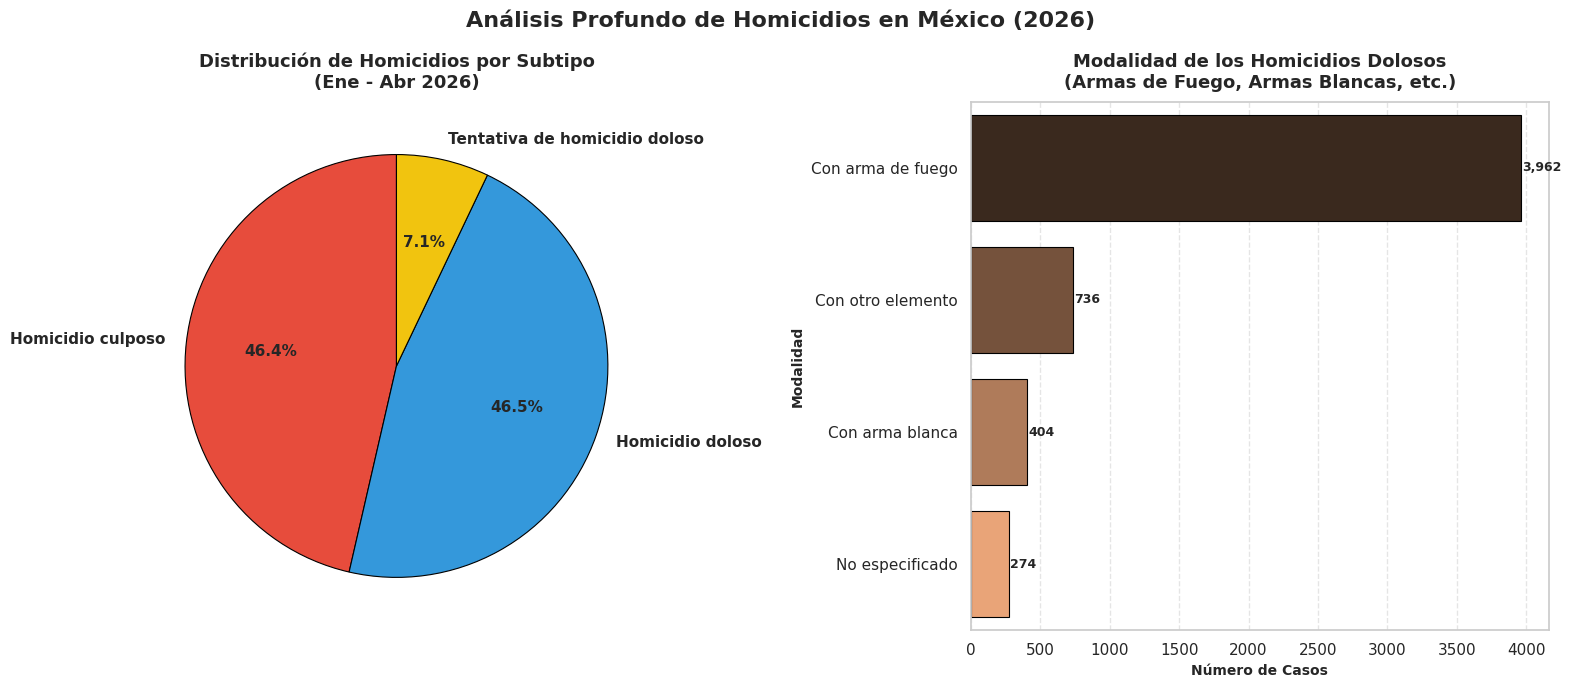

In [17]:
# 3. Filtrar delitos del tipo Homicidio
homicidios = df_tidy[df_tidy['tipo_delito'] == 'Homicidio']

# Agrupar por subtipo de homicidio (doloso vs culposo)
subtipo_homicidios = homicidios.groupby('subtipo_delito')['cantidad'].sum().reset_index()

# Agrupar por modalidad de homicidio doloso (los homicidios culposos son por accidente de tránsito u otros)
homicidios_dolosos = homicidios[homicidios['subtipo_delito'] == 'Homicidio doloso']
modalidades_dolosas = homicidios_dolosos.groupby('modalidad')['cantidad'].sum().sort_values(ascending=False).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Gráfico izquierdo: Tipos de homicidio (doloso vs culposo)
axes[0].pie(
    subtipo_homicidios['cantidad'],
    labels=subtipo_homicidios['subtipo_delito'],
    autopct='%1.1f%%',
    colors=['#e74c3c', '#3498db', '#f1c40f'],
    startangle=90,
    textprops={'fontsize': 11, 'fontweight': 'bold'},
    wedgeprops={'edgecolor': 'black', 'linewidth': 0.8}
)
axes[0].set_title("Distribución de Homicidios por Subtipo\n(Ene - Abr 2026)", fontsize=13, fontweight='bold', pad=10)

# Gráfico derecho: Modalidad de homicidios dolosos
sns.barplot(
    data=modalidades_dolosas,
    x='cantidad',
    y='modalidad',
    palette="copper",
    ax=axes[1],
    edgecolor='black',
    linewidth=0.8
)
axes[1].set_title("Modalidad de los Homicidios Dolosos\n(Armas de Fuego, Armas Blancas, etc.)", fontsize=13, fontweight='bold', pad=10)
axes[1].set_xlabel("Número de Casos", fontsize=10, fontweight='bold')
axes[1].set_ylabel("Modalidad", fontsize=10, fontweight='bold')
axes[1].grid(axis='x', linestyle="--", alpha=0.5)
for i, bar in enumerate(axes[1].patches):
    axes[1].text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2, f"{int(bar.get_width()):,}", va='center', fontsize=9, fontweight='bold')

plt.suptitle("Análisis Profundo de Homicidios en México (2026)", fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


*   **Interpretación:**
    *   El **Homicidio** es el delito más sensible y representativo de la violencia extrema.
    *   En el gráfico circular izquierdo, observamos la proporción entre homicidios culposos (negligentes, principalmente accidentes de tránsito) y homicidios dolosos (intencionales). La correcta tipificación de estas muertes es clave para el diagnóstico de la violencia en el país.
    *   En el gráfico de barras derecho, analizamos las modalidades de los homicidios dolosos. La utilización de **armas de fuego** resalta como la modalidad más frecuente en los crímenes violentos de alto impacto. Esto enfatiza la importancia crítica de diseñar y ejecutar programas de despistolización y de control de armas en las regiones más vulnerables.


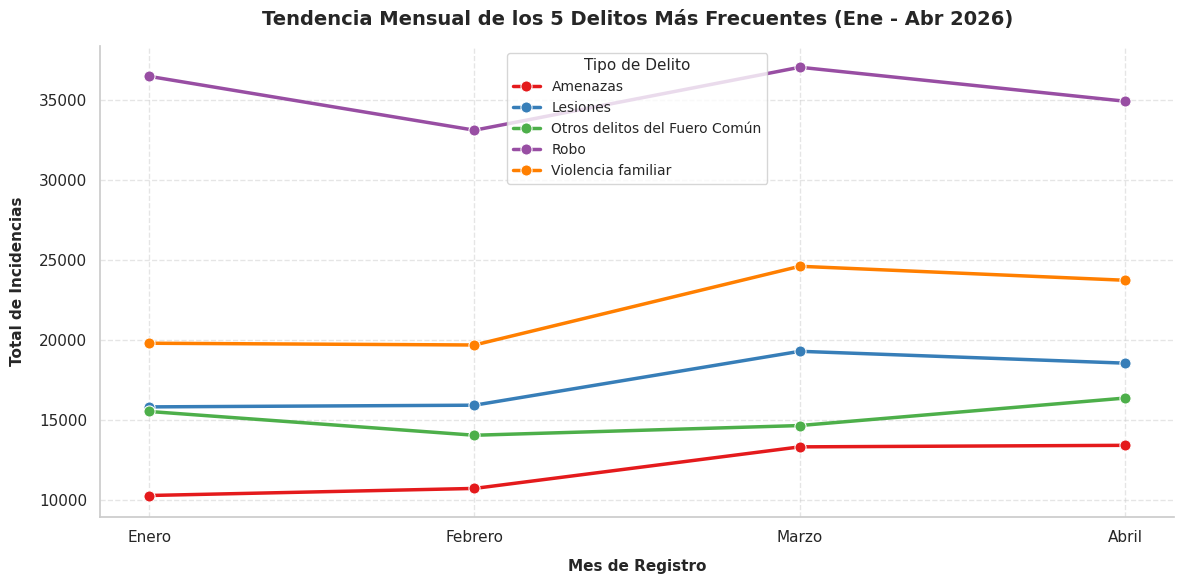

In [18]:
# 4. Obtener las 5 principales categorías de delito por volumen
top_delitos = df_tidy.groupby('tipo_delito')['cantidad'].sum().sort_values(ascending=False).head(5).index.tolist()

# Filtrar el dataframe para incluir solo estas categorías
df_top_temporal = df_tidy[df_tidy['tipo_delito'].isin(top_delitos)]

# Agrupar por tipo de delito y mes para ver la evolución
temporal_stats = df_top_temporal.groupby(['tipo_delito', 'mes'])['cantidad'].sum().reset_index()

# Ordenar los meses para graficar de forma lógica cronológica
meses_ordenados = ['Enero', 'Febrero', 'Marzo', 'Abril']
temporal_stats['mes'] = pd.Categorical(temporal_stats['mes'], categories=meses_ordenados, ordered=True)
temporal_stats = temporal_stats.sort_values(['tipo_delito', 'mes'])

# Graficar la tendencia de delitos
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=temporal_stats,
    x='mes',
    y='cantidad',
    hue='tipo_delito',
    marker='o',
    markersize=8,
    linewidth=2.5,
    palette="Set1"
)

plt.title("Tendencia Mensual de los 5 Delitos Más Frecuentes (Ene - Abr 2026)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Mes de Registro", fontsize=11, fontweight='bold', labelpad=10)
plt.ylabel("Total de Incidencias", fontsize=11, fontweight='bold', labelpad=10)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Tipo de Delito", fontsize=10, title_fontsize=11)
sns.despine()

plt.tight_layout()
plt.show()


*   **Interpretación:**
    *   Este gráfico de líneas permite observar la trayectoria mensual de las 5 categorías más representativas del fuero común.
    *   **Robo** se posiciona consistentemente a la cabeza, manteniendo una tendencia estable con ligeras fluctuaciones mensuales que podrían responder a factores socioeconómicos o dinámicas estacionales del periodo Enero-Abril.
    *   La estabilidad y el paralelismo de las curvas sugieren que las dinámicas delictivas operan bajo patrones consolidados, los cuales requieren intervenciones sistémicas a largo plazo más allá de operativos temporales de reacción inmediata.


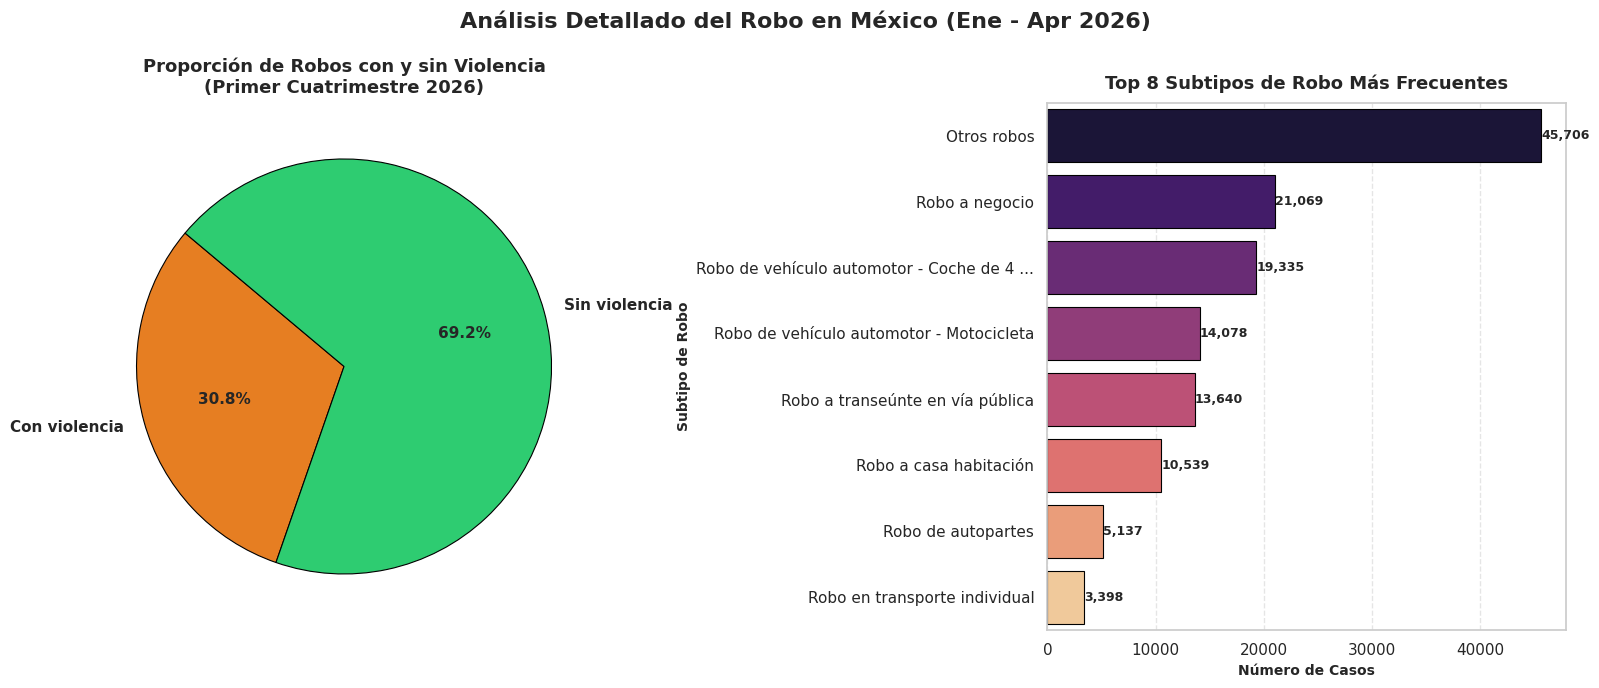

In [19]:
# 5. Filtrar delitos del tipo Robo
robos = df_tidy[df_tidy['tipo_delito'] == 'Robo']

# Agrupar por modalidad (Con violencia vs Sin violencia)
modalidad_robos = robos.groupby('modalidad')['cantidad'].sum().reset_index()

# Agrupar por subtipo de robo y obtener los 8 principales
subtipos_robos = robos.groupby('subtipo_delito')['cantidad'].sum().sort_values(ascending=False).head(8).reset_index()

# Acortar nombres largos de subtipos para mejor visualización
subtipos_robos['subtipo_delito'] = subtipos_robos['subtipo_delito'].apply(lambda x: x[:40] + '...' if len(x) > 40 else x)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Gráfico izquierdo: Modalidad de robo (Con vs Sin violencia)
axes[0].pie(
    modalidad_robos['cantidad'],
    labels=modalidad_robos['modalidad'],
    autopct='%1.1f%%',
    colors=['#e67e22', '#2ecc71'],
    startangle=140,
    textprops={'fontsize': 11, 'fontweight': 'bold'},
    wedgeprops={'edgecolor': 'black', 'linewidth': 0.8}
)
axes[0].set_title("Proporción de Robos con y sin Violencia\n(Primer Cuatrimestre 2026)", fontsize=13, fontweight='bold', pad=10)

# Gráfico derecho: Top 8 Subtipos de robo
sns.barplot(
    data=subtipos_robos,
    x='cantidad',
    y='subtipo_delito',
    palette="magma",
    ax=axes[1],
    edgecolor='black',
    linewidth=0.8
)
axes[1].set_title("Top 8 Subtipos de Robo Más Frecuentes", fontsize=13, fontweight='bold', pad=10)
axes[1].set_xlabel("Número de Casos", fontsize=10, fontweight='bold')
axes[1].set_ylabel("Subtipo de Robo", fontsize=10, fontweight='bold')
axes[1].grid(axis='x', linestyle="--", alpha=0.5)
for i, bar in enumerate(axes[1].patches):
    axes[1].text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2, f"{int(bar.get_width()):,}", va='center', fontsize=9, fontweight='bold')

plt.suptitle("Análisis Detallado del Robo en México (Ene - Apr 2026)", fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


*   **Interpretación:**
    *   Al desglosar el delito de **Robo** (el de mayor frecuencia), encontramos un equilibrio relevante entre robos cometidos **con violencia** y **sin violencia**. Una alta tasa de robos violentos representa un foco rojo para la integridad física de los ciudadanos en su vida cotidiana.
    *   La clasificación por **subtipo de robo** revela de manera clara cuáles son las modalidades que más aquejan a la sociedad: el robo de vehículos, el robo a transeúntes (en vía pública y espacio abierto), el robo a negocio y el robo a casa habitación.
    *   Esta información es esencial para la planeación táctica de patrullajes urbanos y para la prevención del delito, orientando los recursos de seguridad pública a los puntos críticos (paradas de transporte, zonas comerciales y habitacionales).


# 📝 9. Conclusiones y Hallazgos Clave del EDA

1.  **Predominio de Delitos Patrimoniales:** El patrimonio es el bien jurídico más vulnerable en México, concentrando la inmensa mayoría de las carpetas de investigación, impulsado principalmente por las diversas modalidades de robo.
2.  **Distribución Asimétrica del Delito:** Existe una concentración delictiva pronunciada en unas cuantas entidades del país. Esto resalta la necesidad de estrategias de seguridad pública regionalizadas, adaptadas a los volúmenes operativos reales de cada estado.
3.  **Homicidios y Violencia Armada:** Un porcentaje sumamente elevado de homicidios dolosos son perpetrados con **arma de fuego**. Las políticas de desarme y pacificación territorial en los municipios clave son esenciales para reducir esta tasa crítica.
4.  **Estabilidad Temporal a Corto Plazo:** Los delitos más frecuentes muestran tendencias mensuales estables en el primer cuatrimestre de 2026, lo cual sugiere la existencia de patrones estructurales y criminales constantes en el territorio.
5.  **Diversificación del Robo:** El robo a transeúnte, a comercio, de vehículos y a casa habitación son las variantes principales del delito patrimonial. El combate coordinado a estos delitos en micro-zonificaciones específicas puede tener un impacto masivo y positivo en la percepción de seguridad ciudadana.


# has un EDA EN ____(nombre dek archivo)